# COS40007: Vegemite Prescriptive Production System
**Theme 3 - Group 1**

## Team Members
* Pham Thanh Truc Tran - 104813707
* Le Truong Thien Nguyen - 104974280
* Ngoc Huyen Truong - 104995456
* Van Huy Quang Nguyen - 105027350

## Project Overview
This computational notebook details the comprehensive Machine Learning pipeline for the Vegemite Prescriptive Production System. The architecture is engineered to optimize automated industrial manufacturing processes through two primary objectives:

1. **Task 1: Product Quality Classification & Prescriptive Engine**  
   Utilizes a LightGBM classifier to detect early trajectories of product quality drift and a Multi-Output Random Forest Prescriptive Regressor to autonomously recommend optimal Setpoint (SP) interventions, salvaging sub-optimal production batches.

2. **Task 2: Hybrid Downtime Tracking Pipeline**  
   Implements a robust Dual-Stage Machine Learning defense strategy. An Isolation Forest acts as an unsupervised anomaly detection boundary to mitigate false alarms, while a secondary supervised LightGBM model diagnoses the root causes of flagged potential equipment failures.

The pipeline encompasses end-to-end execution, including data profiling, SCADA sensor unification, deterministic imputation, sliding-window feature engineering, comprehensive exploratory data analysis (EDA), and final artifact consolidation for production ecosystem inference.

## 1. Data Profiling & Understanding
Scans the dataset directory to validate shapes, identify missing values, and handle encoding formats (UTF-8/UTF-16) across the raw files to ensure ingestion stability.

In [1]:
import os
import pandas as pd
from IPython.display import display

# ==========================================
# CONFIGURATION & GLOBAL VARIABLES
# ==========================================
DATASET_PATH = '/kaggle/input/datasets/tranphamthanhtruc/theme-3-dataset'

# Dictionary to store all successfully loaded DataFrames.
# Key = File name (without .csv extension), Value = Corresponding DataFrame.
dataframes_dict = {}

def check_data_understanding(dataset_path):
    """
    Recursively scans the directory for CSV files, handles encoding errors 
    during ingestion, and performs initial Exploratory Data Analysis (EDA).
    
    Args:
        dataset_path (str): The root directory path containing the dataset.
        
    Action:
        - Prints dataset dimensions (shape).
        - Checks for and reports missing values (NaNs).
        - Displays a preview of the first 5 rows for quick inspection.
    """
    print(f"Starting to scan directory: {dataset_path}\n" + "="*50)
    
    # Recursively traverse through all subdirectories and files
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith('.csv'):
                # Construct the absolute file path and extract the base file name
                file_path = os.path.join(root, file)
                file_name = os.path.splitext(file)[0] 
                
                print(f"\nOpening file: {file} (from folder: {os.path.basename(root)})")
                
                # ---------------------------------------------------------
                # STEP 1: ENCODING ERROR HANDLING
                # ---------------------------------------------------------
                # Industrial/SCADA system exports often use UTF-16 instead of 
                # standard UTF-8. We attempt UTF-8 first, then fallback to UTF-16.
                try:
                    df = pd.read_csv(file_path, encoding='utf-8')
                except UnicodeDecodeError:
                    print(f"  Warning: UTF-8 decoding failed. Trying UTF-16 encoding...")
                    try:
                        df = pd.read_csv(file_path, encoding='utf-16')
                    except Exception as e:
                        print(f"  Error reading file {file} with UTF-16: {e}")
                        continue # Skip to the next file if fallback also fails
                except Exception as e:
                    print(f"  Unexpected error reading file {file}: {e}")
                    continue

                # If successfully read, store it in the global dictionary for later use
                dataframes_dict[file_name] = df
                
                # ---------------------------------------------------------
                # STEP 2: INITIAL DATA PROFILING (EDA)
                # ---------------------------------------------------------
                
                # 2.1. Check data dimensions (Rows x Columns)
                print(f"  - Shape: {df.shape[0]} rows, {df.shape[1]} columns")
                
                # 2.2. Identify Missing Values (NaNs)
                missing_data = df.isnull().sum()
                cols_with_missing = missing_data[missing_data > 0]
                
                if not cols_with_missing.empty:
                    print(f"  - Missing Values found in {len(cols_with_missing)} columns.")
                else:
                    print("  - No Missing Values found.")
                    
                # 2.3. Statistical Distribution Review
                print("  - Statistical Summary (describe):")
                numeric_cols = df.select_dtypes(include='number').columns
                if not numeric_cols.empty:
                    # Limit the number of columns displayed in the distribution overview to avoid clutter
                    display(df[numeric_cols].describe().T.head(10)) 
                else:
                    print("    No numeric columns found.")
                    
                # 2.4. Visual Data Preview (Highly recommended for Jupyter/Kaggle environments)
                print("  - Data Preview (First 5 rows):")
                display(df.head(5)) 
                print("-" * 50)

# ==========================================
# EXECUTION BLOCK
# ==========================================
# Safely check if the directory exists before executing to prevent FileNotFoundError
if os.path.exists(DATASET_PATH):
    check_data_understanding(DATASET_PATH)
else:
    print(f"Path not found: {DATASET_PATH}")


Starting to scan directory: /kaggle/input/datasets/tranphamthanhtruc/theme-3-dataset

Opening file: set_points_7_good_all.csv (from folder: data_02_07_2019-26-06-2020)
  - Shape: 14341 rows, 7 columns
  - No Missing Values found.
  - Statistical Summary (describe):


,count,mean,std,min,25%,50%,75%,max
Value,14341.0,59.361146,393.47453,-89.0,-71.86,-49.72,73.0,3083.72


  - Data Preview (First 5 rows):


,VYP batch,Part,Employee,Machine,Process,Set Time,Value
0,102_2019_07_02,Yeast - BRN,Ahmed Atta,FFTE,Production solids SP,2019-07-02 00:10:43,41.09
1,102_2019_07_02,Yeast - BRN,Ahmed Atta,TFE,Out flow SP,2019-07-02 00:10:43,2186.05
2,102_2019_07_02,Yeast - BRN,Ahmed Atta,FFTE,Feed solids SP,2019-07-02 00:10:43,50.00
3,102_2019_07_02,Yeast - BRN,Ahmed Atta,FFTE,Steam pressure SP,2019-07-02 00:10:43,118.44
4,102_2019_07_02,Yeast - BRN,Ahmed Atta,TFE,Vacuum pressure SP,2019-07-02 00:10:43,-79.82


--------------------------------------------------

Opening file: set_points_7_list_low_bad_all.csv (from folder: data_02_07_2019-26-06-2020)
  - Shape: 2578 rows, 11 columns
  - No Missing Values found.
  - Statistical Summary (describe):


...

--------------------------------------------------

Opening file: Yeast Prep DT 04_05_20 - 01_07_20.csv (from folder: Downtime)
  - Shape: 218 rows, 14 columns
  - Missing Values found in 2 columns.
  - Statistical Summary (describe):


,count,mean,std,min,25%,50%,75%,max
Dept,218.0,2.000000e+00,0.000000,2.0,2.0,2.0,2.0,2.0
Line,218.0,6.000000e+00,0.000000,6.0,6.0,6.0,6.0,6.0
Sub Line,218.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0
From Product,218.0,1.400339e+06,0.886977,1400338.0,1400338.0,1400339.0,1400340.0,1400340.0
To Product,3.0,1.400339e+06,0.577350,1400338.0,1400338.5,1400339.0,1400339.0,1400339.0
Total Time Mins,218.0,5.997248e+01,46.554949,10.0,28.0,55.0,78.5,375.0
Freq,218.0,1.032110e+00,0.242636,1.0,1.0,1.0,1.0,4.0


  - Data Preview (First 5 rows):


,Production Date,Dept,Line,Sub Line,Time,Shift,Waterfall,From Product,To Product,Cause Category,Cause,Total Time Mins,Freq,Comments
0,4/05/2020,2,6,0,13:30,Daytime,Operational Losses,1400338,NaN,TFE,Low Solids,30,1,Seal Water
1,4/05/2020,2,6,0,15:25,Afternoon,Operational Losses,1400338,NaN,TFE,Low Solids,10,2,Seal Water Fault
2,4/05/2020,2,6,0,15:45,Afternoon,Operational Losses,1400338,NaN,TFE,Low Solids,10,1,Seal Water Fault
3,4/05/2020,2,6,0,18:00,Afternoon,Operational Losses,1400338,NaN,TFE,Low Solids,10,1,Seal Water Fault
4,4/05/2020,2,6,0,20:10,Afternoon,Operational Losses,1400338,NaN,TFE,Low Solids,15,1,Seal Water Fault


--------------------------------------------------


## 2. Quality Sensor Data Unification
Filters raw files by machine groups, unifies target labels automatically from filenames, discards overlapping records, and merges them into a clean master dataset for quality analysis.

In [2]:
import pandas as pd
import os

# ==========================================
# CONFIGURATION & GLOBAL VARIABLES
# ==========================================
DATASET_PATH = '/kaggle/input/datasets/tranphamthanhtruc/theme-3-dataset/Theme3'
OUTPUT_PATH = '/kaggle/working/Cleaned_Merged_Quality_Data.csv'

def merge_quality_sensor_data(dataset_path, output_path):
    """
    Scans the dataset directory for wide-format SCADA sensor files, standardizes 
    the target labels based on filenames, and merges them into a single master dataset.
    
    This function explicitly filters out non-sensor directories and strictly enforces 
    schema requirements to prevent data contamination. It also handles overlapping 
    records by applying a strict deduplication strategy.
    
    Args:
        dataset_path (str): Root directory containing the raw SCADA CSV files.
        output_path (str): Destination path for the final merged CSV.
    """
    print("1. SCANNING AND MERGING ALL AVAILABLE WIDE-FORMAT FILES...\n" + "="*50)

    # Initialize a list to hold all valid DataFrames containing SP/PV sensor data
    frames_to_merge = []

    # ---------------------------------------------------------
    # STEP 1: DIRECTORY TRAVERSAL & FILE FILTERING
    # ---------------------------------------------------------
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith('.csv'):
                file_path = os.path.join(root, file)
                
                # Context Isolation: Skip 'Downtime' and 'Infinity' directories 
                # as they possess fundamentally different schemas and granularities.
                if 'Downtime' in root or 'Infinity' in root:
                    continue
                    
                try:
                    # Encoding Fallback: Industrial SCADA systems frequently export 
                    # in UTF-16. Attempt standard UTF-8 first, fallback if necessary.
                    try:
                        df_temp = pd.read_csv(file_path, encoding='utf-8')
                    except UnicodeDecodeError:
                        df_temp = pd.read_csv(file_path, encoding='utf-16')
                    
                    # ---------------------------------------------------------
                    # STEP 2: SCHEMA ENFORCEMENT & TARGET EXTRACTION
                    # ---------------------------------------------------------
                    # Strict Schema Validation: Only accept "wide-format" files 
                    # (>= 30 columns) to guarantee all necessary sensors are present, 
                    # actively filtering out narrow summary logs (7-11 columns).
                    if df_temp.shape[1] >= 30:
                        
                        # Target Variable Labeling: Infer the quality class logically 
                        # from the standardized file naming conventions.
                        file_lower = file.lower()
                        if 'good' in file_lower:
                            df_temp['Quality_Label'] = 'Good'
                        elif 'low' in file_lower:
                            df_temp['Quality_Label'] = 'Low_Bad'
                        elif 'high' in file_lower:
                            df_temp['Quality_Label'] = 'High_Bad'
                        else:
                            # If the file is a generic 'mixed' or 'process_all' file, 
                            # we process it if it already contains a mapped 'Class' column
                            if 'Class' in df_temp.columns:
                                df_temp['Quality_Label'] = df_temp['Class'].astype(str)
                            else:
                                continue
                                
                        frames_to_merge.append(df_temp)
                        print(f"  Picked up valid Wide file: {file} | Shape: {df_temp.shape}")
                        
                except Exception as e:
                    print(f"  Error reading {file}: {e}")

    # ---------------------------------------------------------
    # STEP 3: CONSOLIDATION & DEDUPLICATION
    # ---------------------------------------------------------
    if not frames_to_merge:
        print("\nCRITICAL ERROR: Could not find any valid files.")
    else:
        # Concatenate all validated dataframes into a single master dataframe
        df_merged = pd.concat(frames_to_merge, ignore_index=True)
        print(f"\nRaw merged shape: {df_merged.shape}")
        
        # Data Integrity Check: Remove overlapping records. Overlaps often occur 
        # when 'mixed' files contain the same batch data as specific quality files.
        # We use a composite key (Batch ID + Machine Part + Timestamp) to ensure uniqueness.
        df_merged = df_merged.drop_duplicates(subset=['VYP batch', 'Part', 'Set Time'])
        print(f"Shape after removing duplicates: {df_merged.shape}")
        
        # Export the clean, ML-ready dataset
        df_merged.to_csv(output_path, index=False)
        print(f"Saved fixed master file to: {output_path}")

    print("\nDATA IS NOW CORRECTLY MERGED WITH NO DUPLICATES.")

# ==========================================
# EXECUTION
# ==========================================
if os.path.exists(DATASET_PATH):
    merge_quality_sensor_data(DATASET_PATH, OUTPUT_PATH)
else:
    print(f"Path not found: {DATASET_PATH}")


1. SCANNING AND MERGING ALL AVAILABLE WIDE-FORMAT FILES...
  Picked up valid Wide file: high bad.csv | Shape: (14495, 34)
  Picked up valid Wide file: low bad.csv | Shape: (2578, 34)
  Picked up valid Wide file: good.csv | Shape: (13302, 34)
  Picked up valid Wide file: set_points_7_with_process_all.csv | Shape: (30375, 32)


/tmp/ipykernel_17/4276384175.py:47: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file_path, encoding='utf-16')
/tmp/ipykernel_17/4276384175.py:47: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file_path, encoding='utf-16')



Raw merged shape: (60750, 35)
Shape after removing duplicates: (19637, 35)
Saved fixed master file to: /kaggle/working/Cleaned_Merged_Quality_Data.csv

DATA IS NOW CORRECTLY MERGED WITH NO DUPLICATES.


## 3. Downtime Log Cleaning
Locates physical equipment downtime logs and normalizes string-based date forms into unified chronological timestamps to act as anchor references for predictive failure windows.

In [3]:
import pandas as pd
import os
from IPython.display import display

# ==========================================
# CONFIGURATION & GLOBAL VARIABLES
# ==========================================
DATASET_PATH = '/kaggle/input/datasets/tranphamthanhtruc/theme-3-dataset/Theme3/Downtime'
OUTPUT_PATH = '/kaggle/working/Cleaned_Downtime.csv'

def clean_downtime_logs(dataset_path, output_path):
    """
    Locates the specific Downtime event log, standardizes data types, 
    and unifies fragmented date/time strings into a single, chronologically 
    sorted datetime object.

    This preprocessing step is critical for Time-Series tasks, as these 
    timestamps will act as the anchor points for generating 'Warning Windows' 
    in the predictive maintenance pipeline.

    Args:
        dataset_path (str): Directory containing the downtime logs.
        output_path (str): Destination path for the cleaned CSV.
    """
    downtime_file_path = None

    # ---------------------------------------------------------
    # STEP 1: FILE DISCOVERY
    # ---------------------------------------------------------
    # Scan the directory specifically for the 'Yeast Prep DT' file, 
    # isolating it from other irrelevant logs in the folder.
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if 'Yeast Prep DT' in file and file.endswith('.csv'):
                downtime_file_path = os.path.join(root, file)
                break

    if downtime_file_path:
        # 1. LOAD THE DATA
        df_downtime = pd.read_csv(downtime_file_path)
        print("FIXING DOWNTIME DATA FORMATS...\n" + "="*50)
        
        # ---------------------------------------------------------
        # STEP 2: DATA TYPE CASTING (NUMERIC)
        # ---------------------------------------------------------
        # Manual industrial logs often contain accidental string characters (e.g., "10 mins" 
        # instead of just "10"). We force numeric conversion, coercing errors to NaN 
        # so they don't break downstream mathematical operations.
        if 'Total Time Mins' in df_downtime.columns:
            df_downtime['Total Time Mins'] = pd.to_numeric(df_downtime['Total Time Mins'], errors='coerce')
            print("Fixed 'Total Time Mins': Successfully converted to numeric duration.")

        # ---------------------------------------------------------
        # STEP 3: TEMPORAL UNIFICATION & SORTING
        # ---------------------------------------------------------
        if 'Production Date' in df_downtime.columns and 'Time' in df_downtime.columns:
            # Combine fragmented Date and Time strings into a single timestamp string
            combined_dt_str = df_downtime['Production Date'].astype(str) + ' ' + df_downtime['Time'].astype(str)
            
            # CRITICAL FIX: Pandas defaults to the US date format (MM/DD/YYYY). 
            # Industrial logs in many regions use DD/MM/YYYY. Setting dayfirst=True 
            # prevents catastrophic misalignment of months and days.
            df_downtime['Start_Datetime'] = pd.to_datetime(combined_dt_str, dayfirst=True, errors='coerce')
            
            # Sort chronologically. This is strictly required because future time-window 
            # mapping (e.g., looking back 30 minutes) relies on ordered temporal data.
            df_downtime = df_downtime.sort_values(by='Start_Datetime').reset_index(drop=True)
            print("Created new unified timestamp: 'Start_Datetime' (Sorted chronologically).")
            
            # ---------------------------------------------------------
            # STEP 4: VALIDATION & PREVIEW
            # ---------------------------------------------------------
            print("\nCLEANED TIME COLUMNS PREVIEW:")
            display(df_downtime[['Production Date', 'Time', 'Start_Datetime', 'Total Time Mins']].head())
            
            # Data Integrity Check: Ensure no timestamps were lost during the string conversion
            failed_conversions = df_downtime['Start_Datetime'].isna().sum()
            if failed_conversions > 0:
                print(f"Warning: {failed_conversions} rows failed datetime conversion.")
            else:
                print("Success: 100% of rows converted to datetime perfectly.")
        
        # ---------------------------------------------------------
        # STEP 5: EXPORT ML-READY LOGS
        # ---------------------------------------------------------
        df_downtime.to_csv(output_path, index=False)
        print(f"\nSaved the properly formatted file to: {output_path}")

    else:
        print("Could not locate the 'Yeast Prep DT' file. Check your dataset folder paths.")

# ==========================================
# EXECUTION
# ==========================================
if os.path.exists(DATASET_PATH):
    clean_downtime_logs(DATASET_PATH, OUTPUT_PATH)
else:
    print(f"Path not found: {DATASET_PATH}")

FIXING DOWNTIME DATA FORMATS...
Fixed 'Total Time Mins': Successfully converted to numeric duration.
Created new unified timestamp: 'Start_Datetime' (Sorted chronologically).

CLEANED TIME COLUMNS PREVIEW:


,Production Date,Time,Start_Datetime,Total Time Mins
0,4/05/2020,13:30,2020-05-04 13:30:00,30
1,4/05/2020,15:25,2020-05-04 15:25:00,10
2,4/05/2020,15:45,2020-05-04 15:45:00,10
3,4/05/2020,18:00,2020-05-04 18:00:00,10
4,4/05/2020,20:10,2020-05-04 20:10:00,15


Success: 100% of rows converted to datetime perfectly.

Saved the properly formatted file to: /kaggle/working/Cleaned_Downtime.csv


## 4. Sensor Value Imputation
Resolves decoding errors inside Continuous Trend logs and securely targets continuous streams using Time-Series Forward-Fill (ffill) to protect against future data leakage.

In [4]:
"""
Sensor Trend Data Pre-processing Pipeline

This script automatically scans, ingests, and cleans industrial continuous 
sensor data (Trend files). It addresses common SCADA data issues including:
1. Encoding inconsistencies (handling UTF-16 exports).
2. Temporal alignment (parsing DD/MM/YYYY formats and sorting chronologically).
3. Time-Series Missing Value Imputation (applying Forward-Fill to maintain 
   physical continuity and strictly avoid future data leakage).
"""

import os
import pandas as pd
from IPython.display import display

# Define the root directory for the dataset
DATASET_PATH = '/kaggle/input/datasets/tranphamthanhtruc/theme-3-dataset/Theme3' 

# Dictionary to hold the cleaned DataFrames in memory
sensor_dfs = {}

print("SCANNING FOR SENSOR TREND FILES...\n" + "="*50)

# Traverse the directory tree to find all relevant sensor files
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        # ---------------------------------------------------------
        # FILE FILTERING
        # ---------------------------------------------------------
        # Looking for files that contain 'Trend' in their name
        if 'Trend' in file and file.endswith('.csv'):
            file_path = os.path.join(root, file)
            file_name = os.path.splitext(file)[0]
            
            print(f"\nProcessing: {file}")
            try:
                # ---------------------------------------------------------
                # 1. READ WITH UTF-16 ENCODING
                # ---------------------------------------------------------
                # Industrial systems (like Rockwell/Allen-Bradley) often export 
                # trend data in UTF-16. This forces pandas to read it correctly.
                df = pd.read_csv(file_path, encoding='utf-16')
                print(f"  Loaded successfully (UTF-16). Shape: {df.shape[0]} rows, {df.shape[1]} columns")
                
                # ---------------------------------------------------------
                # 2. FIX TIME COLUMN & CHRONOLOGICAL SORTING
                # ---------------------------------------------------------
                # Dynamically locate the time column, as naming conventions 
                # might slightly differ across various machine exports.
                time_col = None
                for col in df.columns:
                    if 'time' in col.lower():
                        time_col = col
                        break
                        
                if time_col:
                    print(f"  Converting '{time_col}' to Datetime...")
                    # Using dayfirst=True to properly parse DD/MM/YYYY formats, 
                    # preventing catastrophic month/day swapping errors.
                    df[time_col] = pd.to_datetime(df[time_col], dayfirst=True, errors='coerce')
                    
                    # Sorting chronologically is an absolute prerequisite for 
                    # any time-series task (like rolling averages or imputation).
                    df = df.sort_values(by=time_col).reset_index(drop=True)
                    
                    failed_times = df[time_col].isna().sum()
                    if failed_times > 0:
                        print(f"  Warning: {failed_times} rows failed time conversion.")
                else:
                    print("  Warning: No Time column found in this file!")

                # ---------------------------------------------------------
                # 3. HANDLE MISSING SENSOR VALUES (TIME-SERIES IMPUTATION)
                # ---------------------------------------------------------
                missing_data = df.isnull().sum()
                cols_with_missing = missing_data[missing_data > 0]
                
                if not cols_with_missing.empty:
                    print(f"  Warning: Missing values detected in {len(cols_with_missing)} sensor columns.")
                    print("  Applying Forward Fill (ffill) for time-series continuity...")
                    
                    # Forward fill (ffill) respects the "arrow of time". It uses the 
                    # last known good sensor reading to fill the gap, ensuring Zero Data Leakage.
                    df = df.ffill() 
                    
                    # Backward fill (bfill) is used purely as a safety net for any NaNs 
                    # located at the very first row of the dataset.
                    if df.isnull().sum().sum() > 0:
                        df = df.bfill()
                        
                    print("  All missing values handled.")
                else:
                    print("  No missing sensor values detected.")

                # Save the cleaned dataframe to our dictionary for in-memory use
                sensor_dfs[file_name] = df
                
                # ---------------------------------------------------------
                # 4. EXPORT & PREVIEW
                # ---------------------------------------------------------
                # Replace spaces and hyphens with underscores to create safe, 
                # machine-readable filenames for the output directory.
                safe_name = file_name.replace(" ", "_").replace("-", "_")
                clean_path = f'/kaggle/working/Cleaned_{safe_name}.csv'
                df.to_csv(clean_path, index=False)
                print(f"  Saved cleaned file to: {clean_path}")
                
                # PREVIEW: Display the first 3 rows to verify data integrity
                display(df.head(3))
                
            except Exception as e:
                # Catch and log any unexpected errors (e.g., corrupted files) 
                # without crashing the entire pipeline loop.
                print(f"  Failed to process {file}. Error: {e}")

print("\nFINISHED PROCESSING SENSOR DATA.")

SCANNING FOR SENSOR TREND FILES...

Processing: FFTE Trend 22_06 - 26_06.csv
  Loaded successfully (UTF-16). Shape: 132062 rows, 9 columns
  Converting 'Time' to Datetime...


/tmp/ipykernel_17/4162301064.py:42: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding='utf-16')
/tmp/ipykernel_17/4162301064.py:60: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(df[time_col], dayfirst=True, errors='coerce')


  Applying Forward Fill (ffill) for time-series continuity...
  All missing values handled.
  Saved cleaned file to: /kaggle/working/Cleaned_FFTE_Trend_22_06___26_06.csv


,Time,Port_Melbourne:RSLinx Enterprise:Veg_B.SQL_FFTE_Steam_Pressure,Port_Melbourne:RSLinx Enterprise:Veg_B.SQL_FFTE_Steam_Setpoint,Port_Melbourne:RSLinx Enterprise:Veg_B.SQL_FFTE_Pre_Heat_Temperature1 (Deg C),Port_Melbourne:RSLinx Enterprise:Veg_B.SQL_FFTE_Pre_Heat_Temperature2 (Deg C),Port_Melbourne:RSLinx Enterprise:Veg_B.SQL_FFTE_Pre_Heat_Temperature3 (Deg C),Port_Melbourne:RSLinx Enterprise:Veg_B.SQL_FFTE_Post_Heat_Temperature (Deg C),Port_Melbourne:RSLinx Enterprise:Veg_B.SQL_FFTE_CIP_Supply_Flow,Port_Melbourne:RSLinx Enterprise:Veg_B.SQL_FFTE_Product_Supply_Flow
0,2020-06-22 00:00:50.000,160.20,135.02,71.43,52.31,49.12,50.92,"12,002.51","12,002.51"
1,2020-06-22 00:00:56.127,159.84,135.02,71.43,52.31,49.12,50.92,"12,002.51","12,002.51"
2,2020-06-22 00:01:01.165,159.84,135.02,71.43,52.31,49.12,50.92,"11,983.79","11,983.79"



Processing: Evaporator Trends 18_05 - 22_05.csv


/tmp/ipykernel_17/4162301064.py:42: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding='utf-16')
/tmp/ipykernel_17/4162301064.py:60: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[time_col] = pd.to_datetime(df[time_col], dayfirst=True, errors='coerce')


  Loaded successfully (UTF-16). Shape: 359485 rows, 14 columns
  Converting 'Time' to Datetime...
  Applying Forward Fill (ffill) for time-series continuity...
  All missing values handled.
  Saved cleaned file to: /kaggle/working/Cleaned_Evaporator_Trends_18_05___22_05.csv


,Time,VEG_C.VMLT2007 (%),VEG_B.HMI_VEFC1562.PV (L/Hr),VEG_B.HMI_VEFC1562.SP (L/Hr),VEG_B.HMI_VEFC1062.PV (L/Hr),VEG_B.HMI_VELC1060.PV (%),VEG_B.HMI_VELC1060.SP (%),VEG_B.HMI_VEDC1266.PV (%),VEG_B.HMI_VEDC1266.SP (%),VEG_B.HMI_VEDC1664.SP (%),VEG_B.HMI_VEFC1265.PV (kg/hr),VEG_B.HMI_VEFC1265.SP (kg/hr),VEG_B.HMI_VELC1560.PV (%),VEG_B.HMI_VELC1662.PV (%)
0,2020-05-18 00:00:33.000,4.05,"2,559.07","2,546.90","11,998.79",61.4,48.22,-11.02,41.91,47.83,"2,550.86","2,388.27",39.66,54.46
1,2020-05-18 00:00:36.126,4.05,"2,551.88","2,554.14","11,998.79",61.4,48.22,-11.02,41.91,47.83,"2,411.15","2,388.27",39.81,54.46
2,2020-05-18 00:00:36.153,4.05,"2,551.88","2,554.14","11,998.79",61.4,48.22,-11.02,41.91,47.83,"2,411.15","2,388.27",39.81,54.46



FINISHED PROCESSING SENSOR DATA.


## 5. Downtime Integration & Windowed Features
Merges pre-processed sensor timelines with downtime flags. Re-calculates sliding mechanical features (mean, std, delta) and highlights dynamic early-warning windows prioritizing proactive alerts.

In [5]:
"""
Downtime Event & Sensor Data Integration Pipeline

ML UPGRADE:
- Compute Sliding Window Features (mean, std, min, max, delta) BEFORE MERGING.
- Separate Machine Context (TFE, FFTE, Extract) to avoid noise from grouping.
- LATEST REVERT: Return to 2-cluster architecture (FFTE & TFE). Extract Tank is merged with TFE to overcome data sparsity weakness.
"""

import pandas as pd
import numpy as np
from IPython.display import display
import glob
import os
import re

print("MERGING DOWNTIME EVENTS WITH SENSOR DATA...\n" + "="*50)

dt_path = '/kaggle/working/Cleaned_Downtime.csv'

try:
    df_dt = pd.read_csv(dt_path)
    df_dt['Start_Datetime'] = pd.to_datetime(df_dt['Start_Datetime'])
    df_dt = df_dt.drop_duplicates().sort_values(by='Start_Datetime')
    
    # Try to find a reason/category column for failure type (Updated standard column for Yeast Prep)
    reason_col = next((col for col in ['Cause Category', 'Cause', 'Reason', 'Category', 'Fault', 'Description', 'Equipment', 'Downtime Reason', 'Reason/Fault'] if col in df_dt.columns), None)
    
    print("Loading ALL cleaned sensor files to provide complete system context...")
    sensor_files = glob.glob('/kaggle/working/Cleaned_*.csv')
    sensor_files = [f for f in sensor_files if 'Downtime' not in f and 'Quality' not in f]
    
    processed_dfs = []
    
    for f in sensor_files:
        df_base = pd.read_csv(f)
        
        # 1. MACHINE IDENTIFICATION (Fixing label leakage - Dirty Label)
        fname = os.path.basename(f).upper()
        machines_to_process = []
        if ('TFE' in fname or 'EVAPORATOR' in fname) and 'FFTE' not in fname:
            # Merge TFE and EXTRACT TANK back into 1
            machines_to_process = ['TFE']
        elif 'FFTE' in fname:
            machines_to_process = ['FFTE']
        else:
            machine_name = os.path.basename(f).replace('Cleaned_', '').replace('.csv', '')
            # Clean up dates, 'Trends', and trailing underscores from generic names
            machine_name = re.sub(r'(?i)_trends.*', '', machine_name)  
            machine_name = re.sub(r'_\d+.*', '', machine_name).upper().strip('_')
            machines_to_process = [machine_name]
            
        for machine_name in machines_to_process:
            df_temp = df_base.copy()
            df_temp['Machine_Type'] = machine_name
            
            time_cols = [c for c in df_temp.columns if 'time' in c.lower()]
            if time_cols:
                df_temp.rename(columns={time_cols[0]: 'Time'}, inplace=True)
                df_temp['Time'] = pd.to_datetime(df_temp['Time'])
                df_temp = df_temp.sort_values(by='Time').drop_duplicates().reset_index(drop=True)
                
            # ==========================================
            # 2. SLIDING WINDOW FEATURE ENGINEERING (PER MACHINE)
            # ==========================================
            print(f"  -> Engineering Window Features for Machine: {machine_name} | Rows: {len(df_temp)}")
            numeric_cols = df_temp.select_dtypes(include='number').columns
            
            # Select top 30 sensors to optimize RAM. In practice, can apply to all.
            working_sensors = numeric_cols[:30] 
            window = 10 
            
            for col in working_sensors:
                df_temp[f'{col}_mean'] = df_temp[col].rolling(window=window, min_periods=1).mean()
                df_temp[f'{col}_std']  = df_temp[col].rolling(window=window, min_periods=1).std().fillna(0)
                df_temp[f'{col}_max']  = df_temp[col].rolling(window=window, min_periods=1).max()
                df_temp[f'{col}_min']  = df_temp[col].rolling(window=window, min_periods=1).min()
                df_temp[f'{col}_delta']= df_temp[col] - df_temp[col].shift(window).bfill() # FIX DEPRECATION
                
            # ==========================================
            # IDEA 3: TIME-WINDOW LABELING (MAJOR IMPROVEMENT)
            # ==========================================
            df_temp['Anomaly_Warning'] = 0
            df_temp['Failure_Type'] = 'None'
            
            # REPORT NOTE: 
            # Set up Pre-station Window (Warning Window).
            WARNING_MINUTES = 15
            LEAD_TIME_MINUTES = 10
            warning_window = pd.Timedelta(minutes=WARNING_MINUTES)
            lead_window = pd.Timedelta(minutes=LEAD_TIME_MINUTES)
            
            match_count = 0
            for idx, row in df_dt.iterrows():
                dt_event = row['Start_Datetime']
                if pd.isna(dt_event): continue
                
                reason_val = str(row[reason_col]) if reason_col else 'Unknown'
                reason_upper = reason_val.upper()
                
                # Ignored Extract Tank error skipping code since it is merged
                    
                start_warning = dt_event - warning_window
                end_warning = dt_event - lead_window
                
                # Scan sensor rows falling into this warning time window
                mask = (df_temp['Time'] >= start_warning) & (df_temp['Time'] < end_warning)
                if mask.sum() > 0:
                    df_temp.loc[mask, 'Anomaly_Warning'] = 1
                    df_temp.loc[mask, 'Failure_Type'] = reason_val
                    match_count += 1
                    
            df_temp['Anomaly_Warning'] = df_temp['Anomaly_Warning'].clip(0, 1)
            print(f"     Flagged {match_count} downtime risk patterns for {machine_name}.")
            
            processed_dfs.append(df_temp)

    # 4. MERGE DATA WITH MACHINE_TYPE AND WINDOW FEATURES
    df_sensor = pd.concat(processed_dfs, ignore_index=True)
    
    print("\nTarget Variable Distribution across ALL machines:")
    display(df_sensor['Anomaly_Warning'].value_counts())
    print("\nBreakdown by Machine Type:")
    if 'Machine_Type' in df_sensor.columns:
        display(df_sensor.groupby('Machine_Type')['Anomaly_Warning'].value_counts())

    final_path = '/kaggle/working/ML_Ready_Downtime_Sensors.csv'
    df_sensor.to_csv(final_path, index=False)
    print(f"\nSaved Machine Learning ready dataset to: {final_path}")

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"Error: {e}")

MERGING DOWNTIME EVENTS WITH SENSOR DATA...
Loading ALL cleaned sensor files to provide complete system context...


/tmp/ipykernel_17/1007798575.py:36: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_base = pd.read_csv(f)


  -> Engineering Window Features for Machine: FFTE | Rows: 132062
     Flagged 25 downtime risk patterns for FFTE.
  -> Engineering Window Features for Machine: TFE | Rows: 359485
     Flagged 27 downtime risk patterns for TFE.

Target Variable Distribution across ALL machines:


Anomaly_Warning
0    482383
1      9164
Name: count, dtype: int64


Breakdown by Machine Type:


Machine_Type  Anomaly_Warning
FFTE          0                  129610
              1                    2452
TFE           0                  352773
              1                    6712
Name: count, dtype: int64


Saved Machine Learning ready dataset to: /kaggle/working/ML_Ready_Downtime_Sensors.csv


## 6. EDA: Class Data Imbalance Check
Loads the cleaned quality dataset to visualize the distribution of quality labels across batches. Generating an annotated bar chart helps identify potential class imbalances before training the models.

VISUALIZING CLASS DISTRIBUTION (IMBALANCED DATA CHECK)
Number of samples per Quality Label:
 - High_Bad  : 9381 samples (47.77%)
 - Good      : 8668 samples (44.14%)
 - Low_Bad   : 1587 samples (8.08%)


/tmp/ipykernel_17/1599866266.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index.astype(str), y=counts.values, palette='viridis')


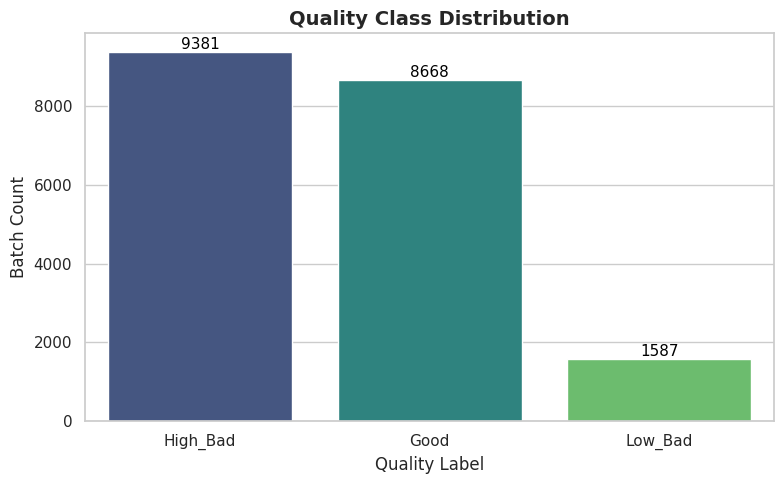

In [6]:
"""
Class Distribution Visualization Script

This script loads the cleaned quality dataset and plots the distribution
of different quality classes to check for data imbalance. It filters out
invalid class labels and annotates the bar chart with exact sample counts.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("VISUALIZING CLASS DISTRIBUTION (IMBALANCED DATA CHECK)\n" + "="*60)
sns.set_theme(style="whitegrid")

qa_path = '/kaggle/working/Cleaned_Merged_Quality_Data.csv'
if os.path.exists(qa_path):
    df_qa = pd.read_csv(qa_path)
    if 'Quality_Label' in df_qa.columns:
        
        # Filter out abnormal classes that might have leaked in (e.g., '1')
        valid_classes = ['Good', 'Low_Bad', 'High_Bad']
        df_qa = df_qa[df_qa['Quality_Label'].isin(valid_classes)]
        
        counts = df_qa['Quality_Label'].value_counts()
        percentages = df_qa['Quality_Label'].value_counts(normalize=True) * 100
        
        print("Number of samples per Quality Label:")
        for label, count in counts.items():
            print(f" - {str(label).ljust(10)}: {count} samples ({percentages[label]:.2f}%)")
            
        plt.figure(figsize=(8, 5))
        
        # Dynamically map colors based on index position instead of hardcoding class names
        ax = sns.barplot(x=counts.index.astype(str), y=counts.values, palette='viridis')
        
        plt.title('Quality Class Distribution', fontweight='bold', fontsize=14)
        plt.ylabel('Batch Count', fontsize=12)
        plt.xlabel('Quality Label', fontsize=12)
        
        # Add numerical data labels on top of each bar
        for p in ax.patches:
            height = int(p.get_height())
            ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                        textcoords='offset points')
                        
        plt.tight_layout()
        plt.show()
else:
    print("Quality Merged dataset file not found!")

## 7. EDA: Multicollinearity & SPvsPV Evaluation
Examines operational multicollinearity via correlation heatmaps and generates time-series charts visualizing real deviations tracking Setpoints (SP) against Process Variables (PV).

EDA: SENSOR CORRELATION & SP/PV TRACKING
1. Correlation Heatmap between Sensors (Top 15 Sensors)


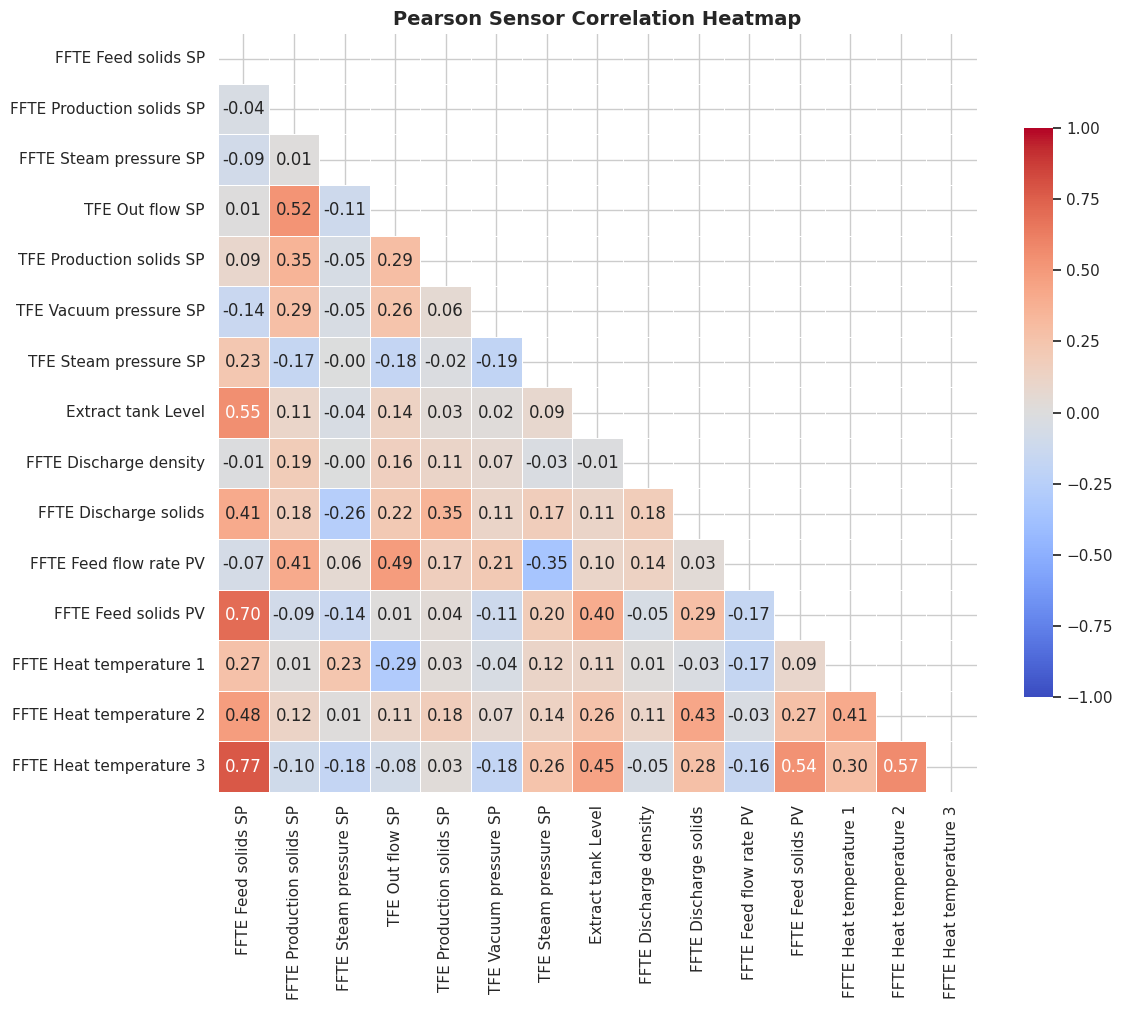


2. Time-series Tracking (Setpoint vs Actual PV Deviation)
  Using time column: 'Set Time'


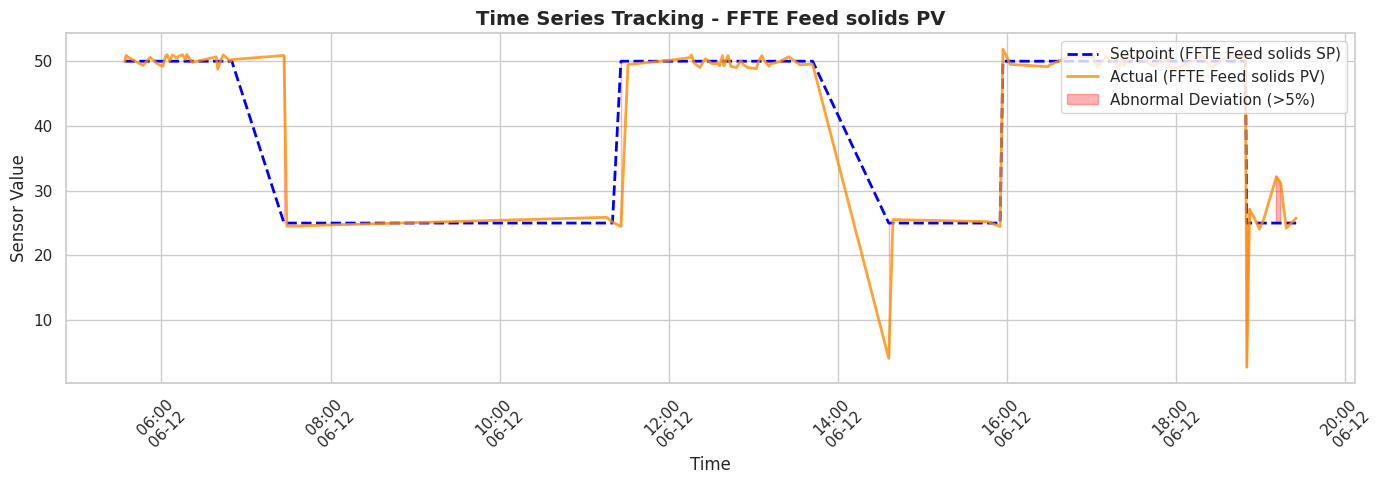

In [7]:
"""
Exploratory Data Analysis: Sensor Correlation and Time-Series Tracking Pipeline.

This script performs two main visual analyses:
1. Correlation Heatmap: Analyzes multicollinearity among the top 15 numerical sensors.
2. SP vs PV Time-Series Tracking: Visualizes the deviation between Setpoint (SP) and 
   Process Variable (PV) over time, highlighting abnormal deviations.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.dates as mdates

print("EDA: SENSOR CORRELATION & SP/PV TRACKING\n" + "="*60)
sns.set_theme(style="whitegrid")

qa_path = '/kaggle/working/Cleaned_Merged_Quality_Data.csv'

if os.path.exists(qa_path):
    df_qa = pd.read_csv(qa_path)
    
    # Get SP (Setpoint) and PV (Process Variable) sensors representing TFE or FFTE machines
    numeric_cols = df_qa.select_dtypes(include=np.number).columns.tolist()
    
    # Skip noisy columns to prevent the heatmap from becoming too dense
    cols_to_drop = ['BatchID', 'Set Time', 'Time', 'Time_Bin']
    sensor_cols = [c for c in numeric_cols if c not in cols_to_drop][:15] # Take the top 15 sensors
    
    # -----------------------------------------------------
    # 1. CORRELATION HEATMAP (MULTICOLLINEARITY)
    # -----------------------------------------------------
    print("1. Correlation Heatmap between Sensors (Top 15 Sensors)")
    plt.figure(figsize=(12, 10))
    
    # Calculate the Pearson correlation matrix
    corr_matrix = df_qa[sensor_cols].corr()
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, 
                square=True, cbar_kws={"shrink": .75}, linewidths=.5)
    
    plt.title('Pearson Sensor Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # -----------------------------------------------------
    # 2. TIME-SERIES TRENDS (SP vs PV TRACKING)
    # -----------------------------------------------------
    print("\n2. Time-series Tracking (Setpoint vs Actual PV Deviation)")
    
    # Automatically detect the time column (e.g., 'Set Time', 'Time', etc.)
    time_cols = [c for c in df_qa.columns if 'time' in c.lower()]
    time_col = time_cols[0] if time_cols else None
    
    if time_col:
        print(f"  Using time column: '{time_col}'")
        df_qa[time_col] = pd.to_datetime(df_qa[time_col], errors='coerce')
        df_time = df_qa.dropna(subset=[time_col]).sort_values(time_col).tail(100) # Take the last 100 timeline records as a sample
        
        # Find a matching SP-PV pair (e.g., Extract Tank or Steam Pressure)
        pv_col_cand = [c for c in df_qa.columns if 'PV' in c]
        valid_pairs = [(pv, pv.replace('PV', 'SP')) for pv in pv_col_cand if pv.replace('PV', 'SP') in df_qa.columns]
        
        if valid_pairs:
            rep_pv, rep_sp = valid_pairs[0]
            
            plt.figure(figsize=(14, 5))
            plt.plot(df_time[time_col], df_time[rep_sp], label=f'Setpoint ({rep_sp})', linestyle='--', color='blue', linewidth=2)
            plt.plot(df_time[time_col], df_time[rep_pv], label=f'Actual ({rep_pv})', color='darkorange', linewidth=2, alpha=0.8)
            
            # Highlight areas with large deviations
            plt.fill_between(df_time[time_col], df_time[rep_sp], df_time[rep_pv], 
                             where=(abs(df_time[rep_sp] - df_time[rep_pv]) > df_time[rep_sp]*0.05),
                             color='red', alpha=0.3, label='Abnormal Deviation (>5%)')
            
            plt.title(f'Time Series Tracking - {rep_pv.split("_")[0]}', fontsize=14, fontweight='bold')
            plt.xlabel('Time', fontsize=12)
            plt.ylabel('Sensor Value', fontsize=12)
            plt.legend(loc='upper right')
            
            # Format the X-axis for better readability
            ax = plt.gca()
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\n%d-%m'))
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print("  Warning: No matching SP/PV pair found in the dataset to plot the line chart.")
    else:
        print("  Warning: Dataset does not have a formatted 'Time' or 'Set Time' column, or it was removed before plotting.")
else:
    print("Error: Merged Quality dataset file not found!")

## 8. EDA: Feature Contribution Analysis
Evaluates the importance of sensors for Quality (Task 1) and Downtime risks (Task 2) using a baseline Random Forest model, exposing which features dominate predictions before the official training phase.

EXPLORATORY DATA ANALYSIS: FEATURE CONTRIBUTION
Purpose: Quickly evaluate the contribution / importance of features within the Dataset
towards Quality (Task 1) and Downtime (Task 2) BEFORE official model training.

1. Calculating Feature Importance for Quality Data...


/tmp/ipykernel_17/2398025095.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_qa, palette='Blues_r')


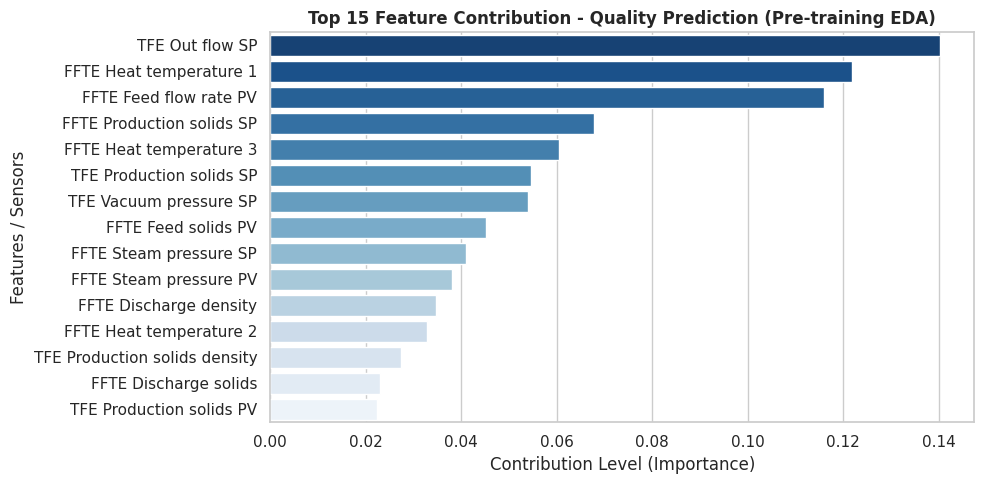


Calculating detailed Feature Importance for each label (OVR: Good, Low_Bad, High_Bad)...


/tmp/ipykernel_17/2398025095.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_ovr, palette=colors[label])
/tmp/ipykernel_17/2398025095.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_ovr, palette=colors[label])
/tmp/ipykernel_17/2398025095.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_ovr, palette=colors[label])


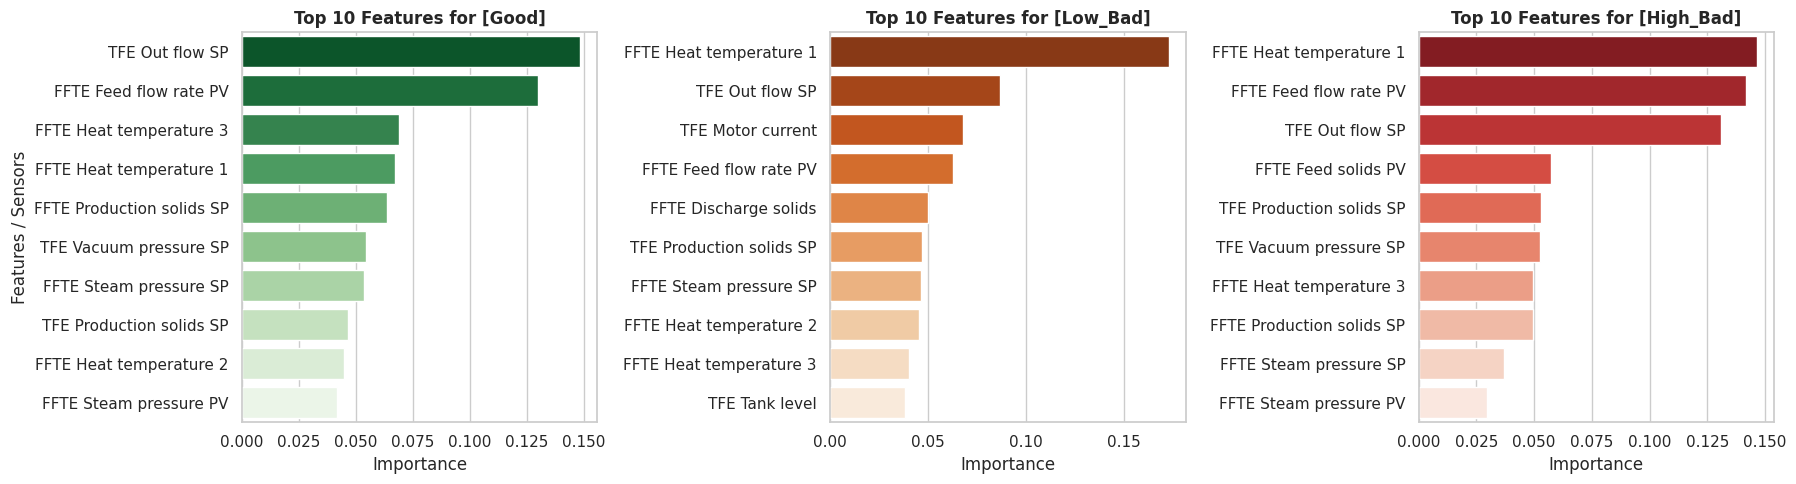


2. Calculating Feature Importance for Downtime Risk Data...


/tmp/ipykernel_17/2398025095.py:95: DtypeWarning: Columns (7,8,41,43,44,45,51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dt = pd.read_csv(dt_path)
/tmp/ipykernel_17/2398025095.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_dt, palette='Reds_r')


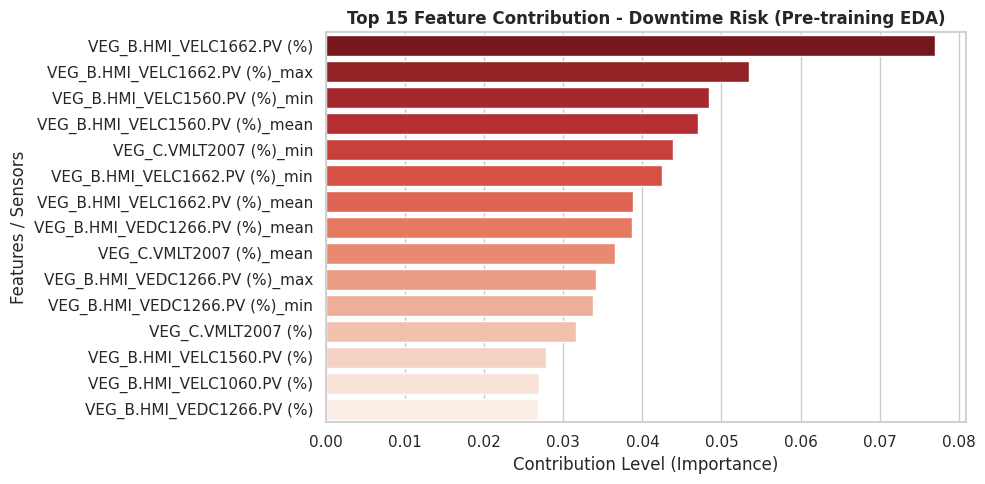

In [8]:
"""
Exploratory Data Analysis: Feature Contribution

This script performs a quick evaluation of feature importance for both 
Quality (Task 1) and Downtime Risk (Task 2) prediction tasks. It uses 
a baseline Random Forest model to determine which features (sensors) 
contribute the most to predicting different target labels before the 
official model training phase.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import os

print("EXPLORATORY DATA ANALYSIS: FEATURE CONTRIBUTION\n" + "="*60)
print("Purpose: Quickly evaluate the contribution / importance of features within the Dataset")
print("towards Quality (Task 1) and Downtime (Task 2) BEFORE official model training.\n")

sns.set_theme(style="whitegrid")

# ==========================================
# 1. QUALITY DATA CONTRIBUTION
# ==========================================
qa_path = '/kaggle/working/Cleaned_Merged_Quality_Data.csv'
if os.path.exists(qa_path):
    print("1. Calculating Feature Importance for Quality Data...")
    df_qa = pd.read_csv(qa_path)
    
    cols_to_drop = ['BatchID', 'Set Time', 'Time', 'Time_Bin']
    df_qa_num = df_qa.drop(columns=[c for c in cols_to_drop if c in df_qa.columns], errors='ignore')
    
    if 'Quality_Label' in df_qa_num.columns:
        df_qa_num = df_qa_num.dropna(subset=['Quality_Label'])
        y_qa = LabelEncoder().fit_transform(df_qa_num['Quality_Label'])
        X_qa = df_qa_num.select_dtypes(include=np.number).ffill().fillna(0)
        
        # Train a quick Random Forest model with 50 trees to find dominating sensors
        rf_qa = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=5, n_jobs=-1)
        rf_qa.fit(X_qa, y_qa)
        
        imp_qa = pd.DataFrame({'Feature': X_qa.columns, 'Importance': rf_qa.feature_importances_})
        imp_qa = imp_qa.sort_values('Importance', ascending=False).head(15)
        
        plt.figure(figsize=(10, 5))
        sns.barplot(x='Importance', y='Feature', data=imp_qa, palette='Blues_r')
        plt.title('Top 15 Feature Contribution - Quality Prediction (Pre-training EDA)', fontweight='bold')
        plt.xlabel('Contribution Level (Importance)')
        plt.ylabel('Features / Sensors')
        plt.tight_layout()
        plt.show()

        print("\nCalculating detailed Feature Importance for each label (OVR: Good, Low_Bad, High_Bad)...")
        # Define 3 colors for the 3 classes
        colors = {'Good': 'Greens_r', 'Low_Bad': 'Oranges_r', 'High_Bad': 'Reds_r'}
        
        plt.figure(figsize=(18, 5))
        for i, label in enumerate(['Good', 'Low_Bad', 'High_Bad']):
            y_binary = (df_qa_num['Quality_Label'] == label).astype(int)
            
            # Apply class_weight='balanced' for Low_Bad and High_Bad due to minority samples
            rf_ovr = RandomForestClassifier(
                n_estimators=50, 
                random_state=42, 
                max_depth=5, 
                n_jobs=-1, 
                class_weight='balanced' if label != 'Good' else None
            )
            rf_ovr.fit(X_qa, y_binary)
            
            imp_ovr = pd.DataFrame({'Feature': X_qa.columns, 'Importance': rf_ovr.feature_importances_})
            imp_ovr = imp_ovr.sort_values('Importance', ascending=False).head(10)
            
            plt.subplot(1, 3, i+1)
            sns.barplot(x='Importance', y='Feature', data=imp_ovr, palette=colors[label])
            plt.title(f'Top 10 Features for [{label}]', fontweight='bold')
            plt.xlabel('Importance')
            if i == 0:
                plt.ylabel('Features / Sensors')
            else:
                plt.ylabel('')
            
        plt.tight_layout()
        plt.show()

# ==========================================
# 2. DOWNTIME DATA CONTRIBUTION
# ==========================================
dt_path = '/kaggle/working/ML_Ready_Downtime_Sensors.csv'
if os.path.exists(dt_path):
    print("\n2. Calculating Feature Importance for Downtime Risk Data...")
    df_dt = pd.read_csv(dt_path)
    
    if 'Anomaly_Warning' in df_dt.columns:
        y_dt = df_dt['Anomaly_Warning']
        cols_to_drop = ['Time', 'Set Time', 'Anomaly_Warning', 'Failure_Class_Name', 'Failure_Type', 'VYP batch', 'Part', 'Machine_Type', 'Failure_Class']
        X_dt = df_dt.select_dtypes(include=np.number).drop(columns=[c for c in cols_to_drop if c in df_dt.columns], errors='ignore').ffill().fillna(0)
        
        # Mandatory class_weight='balanced' because malfunction occurrences are extremely rare 
        rf_dt = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=5, n_jobs=-1, class_weight='balanced')
        rf_dt.fit(X_dt, y_dt)
        
        imp_dt = pd.DataFrame({'Feature': X_dt.columns, 'Importance': rf_dt.feature_importances_})
        imp_dt = imp_dt.sort_values('Importance', ascending=False).head(15)
        
        plt.figure(figsize=(10, 5))
        sns.barplot(x='Importance', y='Feature', data=imp_dt, palette='Reds_r')
        plt.title('Top 15 Feature Contribution - Downtime Risk (Pre-training EDA)', fontweight='bold')
        plt.xlabel('Contribution Level (Importance)')
        plt.ylabel('Features / Sensors')
        plt.tight_layout()
        plt.show()

## 9. Task 1: Product Quality Classification & Prescriptive Engine
Trains a LightGBM classifer to capture product drift and creates a Multi-Output Random Forest Prescriptive Regressor targeting potential intervention setpoints that could mathematically recover failing batches.

STAGE 4: QUALITY CLASSIFICATION & PRESCRIPTIVE ENGINE...
  Shifting Quality Labels forward by 15 steps (Target Shifting)...

PROCESSING PRODUCT: Yeast - FMX
  Initial label distribution:
Quality_Label
2    3973
0    2785
1     672
Name: count, dtype: int64
  Splitting Train/Test Data (Preventing Data Leakage)...
  Balancing data with SMOTE on the Training set...
  Training Classifier to prevent Quality Drift...

  DETAILED METRICS REPORT (QUALITY CLASSIFICATION - Yeast - FMX):
   Accuracy                  : 0.4666
   F1-Score (Macro Average)  : 0.4178

   Confusion Matrix:


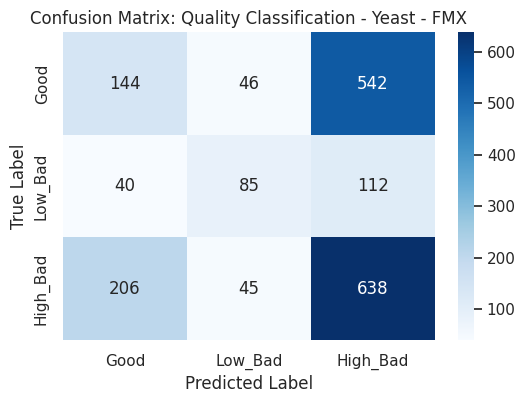


   Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.20      0.26       732
           1       0.48      0.36      0.41       237
           2       0.49      0.72      0.59       889

    accuracy                           0.47      1858
   macro avg       0.45      0.42      0.42      1858
weighted avg       0.44      0.47      0.43      1858


  Initializing Prescriptive Recommender Engine...
     -> Training Recommender on 7 SP nodes...

  STAGE 5: VIRTUAL VALIDATION
      Total bad batches simulated for rescue: 1126
      Average increase in probability of achieving 'Good': +-0.08%
      Number of batches RESCUED to 'Good': 270 / 1126 (24.0%)

PROCESSING PRODUCT: Yeast - BRN
  Initial label distribution:
Quality_Label
0    2014
2    1584
1     369
Name: count, dtype: int64
  Splitting Train/Test Data (Preventing Data Leakage)...
  Balancing data with SMOTE on the Training set...
  Training Classifier to prevent Quality Dr

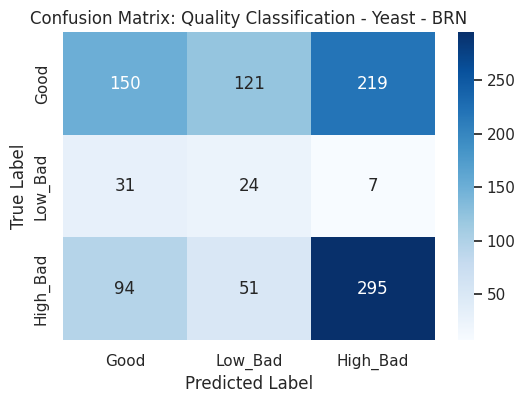


   Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.31      0.39       490
           1       0.12      0.39      0.19        62
           2       0.57      0.67      0.61       440

    accuracy                           0.47       992
   macro avg       0.41      0.45      0.40       992
weighted avg       0.53      0.47      0.48       992


  Initializing Prescriptive Recommender Engine...
     -> Training Recommender on 7 SP nodes...

  STAGE 5: VIRTUAL VALIDATION
      Total bad batches simulated for rescue: 502
      Average increase in probability of achieving 'Good': +-11.92%
      Number of batches RESCUED to 'Good': 57 / 502 (11.4%)

PROCESSING PRODUCT: Yeast - BRD
  Initial label distribution:
Quality_Label
0    3869
2    3809
1     546
Name: count, dtype: int64
  Splitting Train/Test Data (Preventing Data Leakage)...
  Balancing data with SMOTE on the Training set...
  Training Classifier to prevent Quality Drif

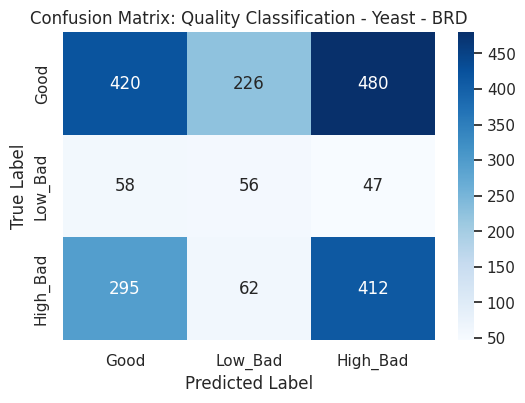


   Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.37      0.44      1126
           1       0.16      0.35      0.22       161
           2       0.44      0.54      0.48       769

    accuracy                           0.43      2056
   macro avg       0.38      0.42      0.38      2056
weighted avg       0.47      0.43      0.44      2056


  Initializing Prescriptive Recommender Engine...
     -> Training Recommender on 7 SP nodes...

  STAGE 5: VIRTUAL VALIDATION
      Total bad batches simulated for rescue: 930
      Average increase in probability of achieving 'Good': +-2.44%
      Number of batches RESCUED to 'Good': 290 / 930 (31.2%)


In [9]:
"""
TASK 1: QUALITY CLASSIFICATION & PRESCRIPTIVE RECOMMENDATION

This module performs the following operations:
1. Feature engineering and data preprocessing for Quality features.
2. Target shifting to provide sufficient lead time for predictions.
3. Training a LightGBM Classifier to detect potential Quality Drift (Good, Low_Bad, High_Bad).
4. Training a Random Forest MultiOutputRegressor as a Prescriptive Engine to recommend optimal Setpoints (SP) to rescue failing batches.
5. Virtual Validation to simulate how many 'Bad' batches could be rescued using the recommended setpoints.
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
import re
warnings.filterwarnings('ignore')

print("STAGE 4: QUALITY CLASSIFICATION & PRESCRIPTIVE ENGINE...\n" + "="*60)

DATA_PATH = '/kaggle/working/Cleaned_Merged_Quality_Data.csv'

try:
    df_q = pd.read_csv(DATA_PATH)
    
    # 1. Feature Engineering
    time_cols = [c for c in df_q.columns if 'time' in c.lower()]
    if time_cols:
        df_q = df_q.sort_values(by=time_cols[0]).reset_index(drop=True)

    non_feature_cols = ['BatchID', 'Quality_Label', 'Testing_Time', 'Time', 'Time_Bin']
    feature_cols = [c for c in df_q.columns if c not in non_feature_cols and np.issubdtype(df_q[c].dtype, np.number)]
    sp_cols = [c for c in feature_cols if 'SP' in c]
    
    # Clean feature names for LightGBM
    clean_features = [re.sub(r'[^A-Za-z0-9_]+', '_', f) for f in feature_cols]
    df_q.rename(columns=dict(zip(feature_cols, clean_features)), inplace=True)
    feature_cols = clean_features
    sp_cols = [re.sub(r'[^A-Za-z0-9_]+', '_', f) for f in sp_cols]
    
    # 2. Target Shifting: Shift target labels backwards to provide adequate Lead Time
    LEAD_TIME_STEPS = 15
    print(f"  Shifting Quality Labels forward by {LEAD_TIME_STEPS} steps (Target Shifting)...")
    
    y_col = 'Quality_Label'
    df_shifted = df_q.copy()
    df_shifted[y_col] = df_q.groupby('BatchID')[y_col].shift(-LEAD_TIME_STEPS) if 'BatchID' in df_q.columns else df_q[y_col].shift(-LEAD_TIME_STEPS)
    df_shifted = df_shifted.dropna(subset=[y_col])
    
    # 3. Label Map
    label_map = {'Good': 0, 'Low_Bad': 1, 'High_Bad': 2}
    inv_label_map = {0: 'Good', 1: 'Low_Bad', 2: 'High_Bad'}
    
    df_shifted[y_col] = df_shifted[y_col].map(label_map)
    df_shifted = df_shifted.dropna(subset=[y_col])
    df_shifted[y_col] = df_shifted[y_col].astype(int)
    
    # Break down per Product Type if possible
    if 'Part' in df_shifted.columns:
        prod_col = 'Part'
    elif 'Product' in df_shifted.columns:
        prod_col = 'Product'
    else:
        prod_col = next((c for c in df_shifted.columns if 'Prod' in c and 'SP' not in c and 'PV' not in c), None)
        
    if not prod_col:
        df_shifted['Fake_Product'] = 'Main_Product'
        prod_col = 'Fake_Product'
        
    unique_prods = df_shifted[prod_col].unique()
    
    # Initialize a Dictionary to store the Model structure for Backend/API export
    models_per_part = {}
    
    for prod in unique_prods:
        print(f"\n==================================================")
        print(f"PROCESSING PRODUCT: {prod}")
        
        df_part = df_shifted[df_shifted[prod_col] == prod].copy()
        
        X = df_part[feature_cols].ffill().fillna(0)
        y = df_part[y_col]
        
        if y.nunique() < 2:
            print("  Warning: Not enough classes. Skipping.")
            continue
            
        print(f"  Initial label distribution:\n{y.value_counts()}")
        
        # -----------------------------------------------------------------
        # TRAIN/TEST SPLIT AND SMOTE
        # -----------------------------------------------------------------
        print("  Splitting Train/Test Data (Preventing Data Leakage)...")
        split_idx = int(len(X) * 0.75)
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
        
        print("  Balancing data with SMOTE on the Training set...")
        try:
            smote = SMOTE(k_neighbors=2, random_state=42)
            X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        except Exception as e:
            print(f"   Warning: SMOTE failed ({e}). Skipping SMOTE.")
            X_train_res, y_train_res = X_train, y_train
            
        # -----------------------------------------------------------------
        # QUALITY CLASSIFICATION MODEL (STAGE 4.1)
        # -----------------------------------------------------------------
        print("  Training Classifier to prevent Quality Drift...")
        
        base_weights = {0: 1, 1: 10, 2: 2} 
        custom_weights = {int(k): base_weights[int(k)] for k in np.unique(y_train_res) if int(k) in base_weights}
        
        base_model = lgb.LGBMClassifier(
            n_estimators=200, 
            max_depth=7,
            learning_rate=0.05,
            class_weight=custom_weights, 
            random_state=42,
            verbose=-1
        )
        base_model.fit(X_train_res, y_train_res)
        
        # 2. "Custom threshold lowering" strategy for Low_Bad class
        y_probs = base_model.predict_proba(X_test)
        y_pred_custom = []
        for p in y_probs:
            if len(p) > 1 and p[1] > 0.20:
                y_pred_custom.append(1)
            else:
                y_pred_custom.append(np.argmax(p))
                
        y_pred_custom = np.array(y_pred_custom)
        
        print(f"\n  DETAILED METRICS REPORT (QUALITY CLASSIFICATION - {prod}):")
        
        acc = accuracy_score(y_test, y_pred_custom)
        f1_mac = f1_score(y_test, y_pred_custom, average='macro', zero_division=0)
        print(f"   Accuracy                  : {acc:.4f}")
        print(f"   F1-Score (Macro Average)  : {f1_mac:.4f}")
        
        print("\n   Confusion Matrix:")
        # 0: Good, 1: Low_Bad, 2: High_Bad
        cm = confusion_matrix(y_test, y_pred_custom, labels=[0,1,2])
        
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Good', 'Low_Bad', 'High_Bad'],
                    yticklabels=['Good', 'Low_Bad', 'High_Bad'])
        plt.title(f'Confusion Matrix: Quality Classification - {prod}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
        
        print("\n   Classification Report:")
        print(classification_report(y_test, y_pred_custom, zero_division=0))
        
        if (y_pred_custom == 0).sum() == len(y_pred_custom) and len(y_test.unique()) > 1:
            print("  [Warning] Model is fully biased. Predicting 100% Good.")
        
        # -----------------------------------------------------------------
        # PRESCRIPTIVE ENGINE (STAGE 4.2)
        # -----------------------------------------------------------------
        print("\n  Initializing Prescriptive Recommender Engine...")
        
        recommender = None
        feature_not_sp = []
        if sp_cols:
            recommender = MultiOutputRegressor(RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42))
            y_sp = X_train_res[sp_cols]
            feature_not_sp = [c for c in X_train_res.columns if c not in sp_cols]
            
            if feature_not_sp:
                print(f"     -> Training Recommender on {len(sp_cols)} SP nodes...")
                recommender.fit(X_train_res[feature_not_sp], y_sp)
        
        # Record BOTH Classification AI and Recommendation AI into the Dictionary
        models_per_part[prod] = {
            'model': base_model, 
            'recommender': recommender,
            'features': list(X_train_res.columns),
            'feature_not_sp': feature_not_sp,
            'sp_cols': sp_cols
        }

        # VIRTUAL VALIDATION
        print("\n  STAGE 5: VIRTUAL VALIDATION")
        bad_mask = y_test != 0
        X_bad = X_test[bad_mask].copy()
        
        if len(X_bad) > 0 and recommender is not None and feature_not_sp:
            original_probs = base_model.predict_proba(X_bad)[:, 0] 
            sp_recommendations = recommender.predict(X_bad[feature_not_sp])
            
            X_rescued = X_bad.copy()
            for idx, sp_col in enumerate(sp_cols):
                orig_val = X_rescued[sp_col].values
                new_val = sp_recommendations[:, idx]
                margin = np.abs(orig_val) * 0.05
                bound_lower = orig_val - np.maximum(margin, 0.5)
                bound_upper = orig_val + np.maximum(margin, 0.5)
                X_rescued[sp_col] = np.clip(new_val, bound_lower, bound_upper)
                
            rescued_probs = base_model.predict_proba(X_rescued)[:, 0]
            prob_diff = rescued_probs - original_probs
            avg_prob_imp = prob_diff.mean() * 100
            
            rescued_preds = []
            rescued_probs_full = base_model.predict_proba(X_rescued)
            for p in rescued_probs_full:
                if len(p) > 1 and p[1] > 0.20:
                    rescued_preds.append(1)
                else:
                    rescued_preds.append(np.argmax(p))
            rescued_preds = np.array(rescued_preds)
            
            success_count = (rescued_preds == 0).sum()
            total_bad = len(X_bad)
            
            print(f"      Total bad batches simulated for rescue: {total_bad}")
            print(f"      Average increase in probability of achieving 'Good': +{avg_prob_imp:.2f}%")
            print(f"      Number of batches RESCUED to 'Good': {success_count} / {total_bad} ({success_count/total_bad*100:.1f}%)")
        else:
            print("      Insufficient conditions to simulate rescue.")

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"Error during Task 1 Execution: {e}")

## 10. Task 2: Hybrid Downtime Tracking Pipeline
Deploys a robust Dual-Stage Machine Learning defense strategy resolving excessive False Alarms. Isolation Forest acts dynamically as an 'Anomaly Detector' while a secondary supervised LightGBM confirms breakdown severity and routes root-cause issues seamlessly.

TASK 2: INITIATING ADVANCED HYBRID DOWNTIME CLASSIFICATION...

PROCESSING MACHINE: TFE
  Splitting along the time axis (Chronological Split)...
    Train: 269613 rows (5727 faults)
    Test:  89872 rows (985 faults)

  STAGE 1: HYBRID SYSTEM (Isolation Forest -> LightGBM)...
    -> Dynamic activation threshold (Top 15% riskiest): 0.0452

  STAGE 1 PERFORMANCE REPORT (ALARM DETECTION) - TEST SET (TFE):
   Accuracy : 0.8020
   Precision: 0.0270 (Alarm reliability)
   Recall   : 0.4873 (Ability to catch true faults)
   F1-Score : 0.0512

   Confusion Matrix Stage 1:


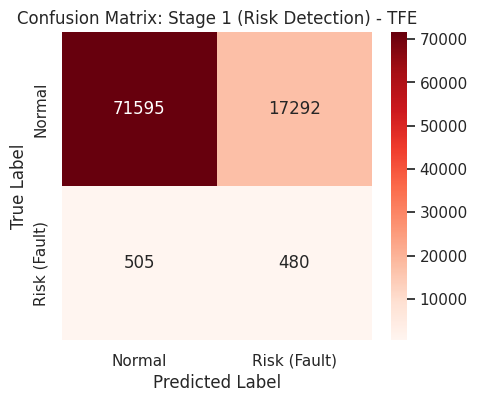


   Classification Report (Stage 1):
              precision    recall  f1-score   support

  0 (Normal)       0.99      0.81      0.89     88887
    1 (Risk)       0.03      0.49      0.05       985

    accuracy                           0.80     89872
   macro avg       0.51      0.65      0.47     89872
weighted avg       0.98      0.80      0.88     89872


  STAGE 2: Training Branching Root Cause Diagnosis
    -> Training multi-branch diagnosis: 2 fault types (using grouped classes).

  END-TO-END PIPELINE TESTING (DETECTION + ORIGINAL DIAGNOSIS): MACHINE TFE
   End-to-End Pipeline Accuracy                  : 0.8042
   Overall F1-Score (Macro Average)              : 0.3323

  End-to-End Classification Report (Breakdown):
                  precision    recall  f1-score   support

          Normal       1.00      0.81      0.89     88887
TFE_Other_Faults       0.03      0.48      0.06       489
    TFE_Shutdown       0.02      1.00      0.05       243

        accuracy             

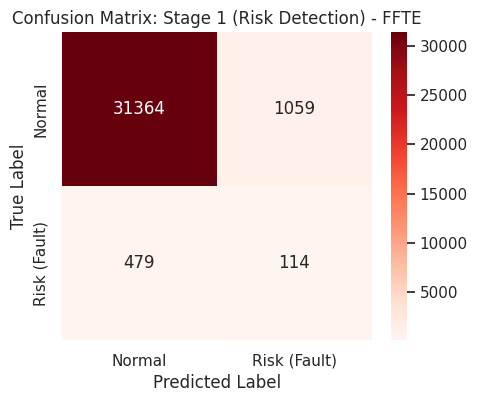


   Classification Report (Stage 1):
              precision    recall  f1-score   support

  0 (Normal)       0.98      0.97      0.98     32423
    1 (Risk)       0.10      0.19      0.13       593

    accuracy                           0.95     33016
   macro avg       0.54      0.58      0.55     33016
weighted avg       0.97      0.95      0.96     33016


  STAGE 2: Training Branching Root Cause Diagnosis
    -> Training multi-branch diagnosis: 2 fault types (using grouped classes).

  END-TO-END PIPELINE TESTING (DETECTION + ORIGINAL DIAGNOSIS): MACHINE FFTE
   End-to-End Pipeline Accuracy                  : 0.9533
   Overall F1-Score (Macro Average)              : 0.3366

  End-to-End Classification Report (Breakdown):
                   precision    recall  f1-score   support

FFTE_Other_Faults       0.00      0.00      0.00       277
    FFTE_Shutdown       0.02      0.06      0.03       214
           Normal       0.98      0.97      0.98     32423

         accuracy       

In [10]:
"""
TASK 2: HYBRID SPECIALIST DOWNTIME PIPELINE (FALSE ALARM RESOLUTION)

System Upgrades for False Alarm Mitigation:
A. Dynamic Thresholds: Use the 85th percentile to target the top 15% most critical risk signals instead of a hardcoded threshold. Automatically balances Precision and Recall.
B. Time-Lagged Features (Short-term memory): Inject PV sensor values from 5 minutes prior to capture temporal context.
C. Hybrid Model (Selective Semi-Supervised): Isolation Forest hunts for "Anomalies" (generating an Anomaly Score). A LightGBM acts as the "Judge", using the Anomaly Score + original features to determine real Downtime risks.
D. Feature Expansion: Add Cumulative Volatility (30-minute rolling standard deviation) derived from SP_PV_Delta to detect instability.
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

print("TASK 2: INITIATING ADVANCED HYBRID DOWNTIME CLASSIFICATION...\n" + "="*60)

ML_READY_DATA_PATH = '/kaggle/working/ML_Ready_Downtime_Sensors.csv'

# COLUMN NAME MAPPING TO SYNCHRONIZE WITH BACKEND UI AND IDENTIFY EXTRACT TANK TAGS INSIDE TFE
TAG_TO_FRIENDLY_MAP = {
    "FFTE_Steam_Pressure_SP": "FFTE Steam pressure SP",
    "FFTE_Steam_Pressure": "FFTE Steam pressure PV",
    "FFTE_Pre_Heat_Temperature1": "FFTE Heat temperature 1",
    "FFTE_Pre_Heat_Temperature2": "FFTE Heat temperature 2",
    "FFTE_Pre_Heat_Temperature3": "FFTE Heat temperature 3",
    "FFTE_Post_Heat_Temperature": "TFE Product out temperature",
    "VELC1060.PV": "Extract tank Level PV",
    "VELC1060_PV": "Extract tank Level PV",
    "VELC1060.SP": "Extract tank Level SP",
    "VELC1060_SP": "Extract tank Level SP",
    "VELC1662.PV": "TFE Tank level PV",
    "VELC1662_PV": "TFE Tank level PV",
    "VMLT2007": "TFE Level PV",
    "VEDC1266.PV": "TFE Vacuum pressure PV",
    "VEDC1266_PV": "TFE Vacuum pressure PV",
    "VEDC1664.SP": "TFE Out flow SP",
    "VEDC1664_SP": "TFE Out flow SP"
}

def map_to_friendly(col_name):
    # Use 'in' instead of 'startswith' to capture variations (dots, underscores) from Allen-Bradley SCADA
    # UPDATE: Need to sort by length DESC so tags with suffixes like _SP aren't mistakenly matched to shorter tag bases
    for tag in sorted(TAG_TO_FRIENDLY_MAP.keys(), key=len, reverse=True):
        if tag in col_name:
            return TAG_TO_FRIENDLY_MAP[tag]
    return col_name

try:
    df_dt_ml = pd.read_csv(ML_READY_DATA_PATH)
    df_dt_ml.rename(columns=lambda x: map_to_friendly(x), inplace=True)
    
    # Filter out duplicate columns if they unexpectedly appear
    df_dt_ml = df_dt_ml.loc[:, ~df_dt_ml.columns.duplicated()]
    
    df_dt_ml['Time'] = pd.to_datetime(df_dt_ml['Time'])
    df_dt_ml = df_dt_ml.sort_values('Time').reset_index(drop=True)
    
    # -----------------------------------------------------------------
    # B. FEATURE ENGINEERING: SP vs PV CONFLICTS AND TIME-LAGGED FEATURES
    # -----------------------------------------------------------------
    pv_cols = [c for c in df_dt_ml.columns if 'PV' in c]
    for pv_col in pv_cols:
        # Add Time-lagged Features: Short-term memory (values from 5 minutes ago)
        df_dt_ml[f'{pv_col}_lag5'] = df_dt_ml[pv_col].shift(5).bfill()
        
        sp_col = pv_col.replace('PV', 'SP')
        if sp_col in df_dt_ml.columns:
            err_col = pv_col.replace('PV', 'SP_PV_Delta')
            pv_numeric = pd.to_numeric(df_dt_ml[pv_col], errors='coerce').fillna(0)
            sp_numeric = pd.to_numeric(df_dt_ml[sp_col], errors='coerce').fillna(0)
            df_dt_ml[err_col] = pv_numeric - sp_numeric
            # Calculate 30-minute rolling standard deviation (cumulative volatility) of the error
            df_dt_ml[f'{err_col}_volatility'] = df_dt_ml[err_col].rolling(window=30, min_periods=1).std().fillna(0)

    # -----------------------------------------------------------------
    # LABELING LOGIC (CLASS STANDARDIZATION)
    # -----------------------------------------------------------------
    df_dt_ml['Failure_Class_Name'] = 'Normal'
    mask = df_dt_ml['Anomaly_Warning'] == 1
    
    if 'Failure_Type' in df_dt_ml.columns and 'Machine_Type' in df_dt_ml.columns:
        valid_reason_mask = mask & (df_dt_ml['Failure_Type'] != 'None')
        df_dt_ml.loc[valid_reason_mask, 'Failure_Class_Name'] = df_dt_ml.loc[valid_reason_mask, 'Machine_Type'].astype(str) + "_" + df_dt_ml.loc[valid_reason_mask, 'Failure_Type'].astype(str)
        
        residual_mask = mask & (df_dt_ml['Failure_Class_Name'] == 'Normal')
        df_dt_ml.loc[residual_mask, 'Failure_Class_Name'] = df_dt_ml.loc[residual_mask, 'Machine_Type'].astype(str) + "_Unknown_Failure"
    elif 'Machine_Type' in df_dt_ml.columns:
        df_dt_ml.loc[mask, 'Failure_Class_Name'] = df_dt_ml.loc[mask, 'Machine_Type'].astype(str) + "_Failure"

    df_dt_ml['Failure_Class_Name'] = df_dt_ml['Failure_Class_Name'].apply(lambda x: re.sub(r'[^A-Za-z0-9_]+', '_', str(x)))

    # GROUP CLASSES: Group rare faults to prevent model 'Class Collapse'
    def group_minor_faults(val):
        if val == 'Normal': return val
        prefix = str(val).split('_')[0]
        v_low = str(val).lower()
        if 'shutdown' in v_low: return f"{prefix}_Shutdown"
        if 'sanitation' in v_low: return f"{prefix}_Sanitation"
        return f"{prefix}_Other_Faults"
    
    df_dt_ml['Failure_Class_Name'] = df_dt_ml['Failure_Class_Name'].apply(group_minor_faults)

    exclude_from_features = ['Time', 'Anomaly_Warning', 'Failure_Class_Name', 'Failure_Type', 'Set Time', 'VYP batch', 'Part', 'Machine_Type', 'Failure_Class']
    features = [c for c in df_dt_ml.select_dtypes(include='number').columns if c not in exclude_from_features]
    
    df_dt_ml[features] = df_dt_ml[features].ffill().fillna(0)
    
    clean_features = [re.sub(r'[^A-Za-z0-9_]+', '_', f) for f in features]
    df_dt_ml = df_dt_ml.rename(columns=dict(zip(features, clean_features)))
    
    machines = df_dt_ml['Machine_Type'].unique()
    models_per_machine = {}
    
    for machine in machines:
        print(f"\n==================================================")
        print(f"PROCESSING MACHINE: {machine}")
        
        df_part = df_dt_ml[df_dt_ml['Machine_Type'] == machine].copy()
        
        # CHANGED: Lowered the threshold from 50 to 5 to allow TFE and EXTRACT_TANK models to be trained 
        # even if they have fewer anomaly minutes mapped during the DT file merge.
        if df_part['Anomaly_Warning'].sum() < 5:
             print(f"  Skipping {machine} due to insufficient failure cases (<5 mins) for machine learning analysis.")
             continue
             
        X = df_part[clean_features]
        y1_stage1 = df_part['Anomaly_Warning']
        y2_stage2 = df_part['Failure_Class_Name']
        
        # -----------------------------------------------------------------
        # CHRONOLOGICAL SPLIT (PREVENT DATA LEAKAGE)
        # -----------------------------------------------------------------
        print("  Splitting along the time axis (Chronological Split)...")
        
        split_idx = int(len(df_part) * 0.75)
        
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y1_train, y1_test = y1_stage1.iloc[:split_idx], y1_stage1.iloc[split_idx:]
        y2_train, y2_test = y2_stage2.iloc[:split_idx], y2_stage2.iloc[split_idx:]

        print(f"    Train: {len(X_train)} rows ({int(y1_train.sum())} faults)")
        print(f"    Test:  {len(X_test)} rows ({int(y1_test.sum())} faults)")
        
        if y1_train.sum() == 0 or y1_test.sum() == 0:
            print("  Still insufficient fault data to distribute. Bypassing.")
            continue
            
        # -----------------------------------------------------------------
        # C. HYBRID STAGE 1: ISOLATION FOREST + LIGHTGBM SEMI-SUPERVISED
        # -----------------------------------------------------------------
        print(f"\n  STAGE 1: HYBRID SYSTEM (Isolation Forest -> LightGBM)...")
        
        # STEP 1: ISOLATION FOREST - ANOMALY DETECTION
        scaler = StandardScaler()
        X_train_normal = X_train[y1_train == 0]
        X_train_normal_scaled = scaler.fit_transform(X_train_normal)
        
        iso_stage1 = IsolationForest(
            n_estimators=300,
            max_samples='auto',
            contamination=0.05, 
            random_state=42,
            n_jobs=-1
        )
        iso_stage1.fit(X_train_normal_scaled)
        
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Calculate 'Anomaly Score' (higher score = more anomalous)
        train_anomaly_scores = -iso_stage1.decision_function(X_train_scaled)
        test_anomaly_scores = -iso_stage1.decision_function(X_test_scaled)
        
        # STEP 2: CREATE NEW FEATURES FOR LIGHTGBM (THE JUDGE)
        X_train_hybrid = X_train.copy()
        X_test_hybrid = X_test.copy()
        X_train_hybrid['IF_Anomaly_Score'] = train_anomaly_scores
        X_test_hybrid['IF_Anomaly_Score'] = test_anomaly_scores
        
        # The Judge model will mildly balance classes (using 'balanced' weight)
        lgb_stage1 = lgb.LGBMClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            class_weight='balanced',
            random_state=42,
            verbose=-1
        )
        lgb_stage1.fit(X_train_hybrid, y1_train)
        
        # -----------------------------------------------------------------
        # A. DYNAMIC THRESHOLDING TO OPTIMIZE PRECISION AND RECALL BALANCE
        # -----------------------------------------------------------------
        y1_train_probs = lgb_stage1.predict_proba(X_train_hybrid)[:, 1]
        y1_test_probs = lgb_stage1.predict_proba(X_test_hybrid)[:, 1]
        
        # Use dynamic percentile-based thresholding
        # Take the 85th percentile of predicted probabilities on the TRAIN set:
        # Trigger alarms only for the top 15% highest risk moments
        best_thresh = np.percentile(y1_train_probs, 85)
        print(f"    -> Dynamic activation threshold (Top 15% riskiest): {best_thresh:.4f}")
            
        y1_test_preds = (y1_test_probs >= best_thresh).astype(int)
        
        print(f"\n  STAGE 1 PERFORMANCE REPORT (ALARM DETECTION) - TEST SET ({machine}):")
        
        acc1 = accuracy_score(y1_test, y1_test_preds)
        prec1 = precision_score(y1_test, y1_test_preds, zero_division=0)
        rec1 = recall_score(y1_test, y1_test_preds, zero_division=0)
        f1_1 = f1_score(y1_test, y1_test_preds, zero_division=0)
        
        print(f"   Accuracy : {acc1:.4f}")
        print(f"   Precision: {prec1:.4f} (Alarm reliability)")
        print(f"   Recall   : {rec1:.4f} (Ability to catch true faults)")
        print(f"   F1-Score : {f1_1:.4f}")
        
        print("\n   Confusion Matrix Stage 1:")
        cm1 = confusion_matrix(y1_test, y1_test_preds, labels=[0, 1])
        
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm1, annot=True, fmt='d', cmap='Reds', 
                    xticklabels=['Normal', 'Risk (Fault)'],
                    yticklabels=['Normal', 'Risk (Fault)'])
        plt.title(f'Confusion Matrix: Stage 1 (Risk Detection) - {machine}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
        
        print("\n   Classification Report (Stage 1):")
        print(classification_report(y1_test, y1_test_preds, target_names=['0 (Normal)', '1 (Risk)'], zero_division=0))
        
        # -----------------------------------------------------------------
        # STAGE 2: ROOT CAUSE DIAGNOSIS USING LIGHTGBM (SUPERVISED)
        # COMPLETELY REMOVE SANITATION-RELATED FAULTS 
        # -----------------------------------------------------------------
        print(f"\n  STAGE 2: Training Branching Root Cause Diagnosis")
        
        mask_train_risk = (y1_train == 1) & (~y2_train.str.lower().str.contains("sanitation", na=False))
        X_train_s2 = X_train_hybrid[mask_train_risk]
        y2_train_s2 = y2_train[mask_train_risk]
        
        unique_causes = y2_train_s2.nunique()
        lgb_stage2 = None
        le_stage2 = None
        fallback_cause = "Unknown_Failure"
        
        if unique_causes > 1:
            print(f"    -> Training multi-branch diagnosis: {unique_causes} fault types (using grouped classes).")
            le_stage2 = LabelEncoder()
            y2_train_s2_enc = le_stage2.fit_transform(y2_train_s2)
            
            # UPDATE: Added class_weight='balanced' to resolve 0.00 scores for rare fault types
            objective_type = 'binary' if unique_causes == 2 else 'multiclass'
            lgb_stage2 = lgb.LGBMClassifier(
                n_estimators=100,
                max_depth=5,
                learning_rate=0.05,
                class_weight='balanced',
                objective=objective_type,
                random_state=42,
                verbose=-1
            )
            lgb_stage2.fit(X_train_s2, y2_train_s2_enc)
        else:
            fallback_cause = y2_train_s2.iloc[0] if len(y2_train_s2) > 0 else "Unknown_Failure"
            print(f"    Only 1 fault type available for diagnosis in {machine}, keeping original label as {fallback_cause}")

        # -----------------------------------------------------------------
        # EVALUATING END-TO-END PIPELINE 
        # CALCULATING METRICS WITHOUT SANITATION FAULTS FOR A CLEANER REPORT
        # -----------------------------------------------------------------
        print(f"\n  END-TO-END PIPELINE TESTING (DETECTION + ORIGINAL DIAGNOSIS): MACHINE {machine}")
        final_preds = np.array(['Normal'] * len(y1_test_preds), dtype=object)
        risk_indices = np.where(y1_test_preds == 1)[0]
        
        if len(risk_indices) > 0:
            X_test_risks = X_test_hybrid.iloc[risk_indices]
            if lgb_stage2 is not None and le_stage2 is not None:
                cause_preds_enc = lgb_stage2.predict(X_test_risks)
                cause_preds = le_stage2.inverse_transform(cause_preds_enc)
                final_preds[risk_indices] = cause_preds
            else:
                final_preds[risk_indices] = fallback_cause
                
        # Remove Sanitation from the report (Extract mask without Sanitation from actual y2_test)
        # Also filter final_preds
        test_no_sanitation_mask = ~y2_test.str.lower().str.contains("sanitation", na=False)
        y2_test_filtered = y2_test[test_no_sanitation_mask]
        final_preds_filtered = final_preds[test_no_sanitation_mask]
        
        acc_end2end = accuracy_score(y2_test_filtered, final_preds_filtered)
        f1_end2end = f1_score(y2_test_filtered, final_preds_filtered, average='macro', zero_division=0)
        
        print(f"   End-to-End Pipeline Accuracy                  : {acc_end2end:.4f}")
        print(f"   Overall F1-Score (Macro Average)              : {f1_end2end:.4f}")
        
        print("\n  End-to-End Classification Report (Breakdown):")
        print(classification_report(y2_test_filtered, final_preds_filtered, zero_division=0))
        
        # SAVE TO GLOBAL MODEL DICTIONARY PREPARING FOR BACKEND EXPORT
        models_per_machine[machine] = {
            'stage1_iso_model': iso_stage1,
            'stage1_scaler': scaler,
            'stage1_lgb_model': lgb_stage1,
            'stage1_thresh': best_thresh,
            'stage2_model': lgb_stage2,
            'stage2_encoder': le_stage2,
            'stage2_fallback': fallback_cause,
            'features': list(X_train.columns)
        }

    # -----------------------------------------------------------------
    # SIMULATING REAL-TIME AWARENESS FROM FINAL MODEL
    # -----------------------------------------------------------------
    if models_per_machine:
        last_eval_machine = list(models_per_machine.keys())[-1]
        print(f"\nREAL-TIME MONITORING SIMULATION (Machine: {last_eval_machine}):")
        
        pack = models_per_machine[last_eval_machine]
        m1_iso = pack['stage1_iso_model']
        scaler = pack['stage1_scaler']
        m1_lgb = pack['stage1_lgb_model']
        thres = pack['stage1_thresh']
        m2 = pack['stage2_model']
        le2 = pack['stage2_encoder']
        fb = pack['stage2_fallback']
        
        recent_sample = X_test.iloc[-1:] 
        recent_sample_scaled = scaler.transform(recent_sample)
        recent_anomaly_score = -m1_iso.decision_function(recent_sample_scaled)[0]
        
        recent_sample_hybrid = recent_sample.copy()
        recent_sample_hybrid['IF_Anomaly_Score'] = recent_anomaly_score
        
        prob_risk = m1_lgb.predict_proba(recent_sample_hybrid)[0, 1]
        is_risk = int(prob_risk >= thres)
        
        if not is_risk:
            print(f"  Machine Status: STABLE (Risk Prob: {prob_risk:.4f} < Threshold {thres:.4f})")
        else:
            print(f"  RISK ALERT! (Risk Prob: {prob_risk:.4f} exceeds safe threshold)")
            if m2 is not None and le2 is not None:
                cause_pred_enc = m2.predict(recent_sample_hybrid)[0]
                cause_pred = le2.inverse_transform([cause_pred_enc])[0]
                print(f"   Root cause diagnosis: {cause_pred}")
            else:
                print(f"   Root cause diagnosis: {fb}")

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"Error during Task 2 Execution: {e}")

## 11. Checkpoint Consolidation: Feature & Artifact Export
Exports all generated ML Models, Encoders, Scalers, and pipeline configurations into `.joblib` & `.json` formats for Backend UI connectivity and production inference.

In [11]:
"""
MODEL AND CONFIGURATION EXPORT

This module exports the trained models, scalers, encoders, and feature configurations
to disk. These artifacts are organized into 'models' and 'config' directories
for seamless integration and deployment to the Backend/API environment.
"""

import joblib
import json
import os

print("INITIATING MODEL & CONFIG EXPORT FOR BACKEND...\n" + "="*60)

# Create folders if they don't exist
os.makedirs('/kaggle/working/models', exist_ok=True)
os.makedirs('/kaggle/working/config', exist_ok=True)

# === EXPORT TASK 1 ===
try:
    task1_features_dict = {}
    if 'models_per_part' in globals():
        for part, model_info in models_per_part.items():
            safe_part_name = str(part).replace(" ", "_").replace("-", "")
            
            # Export Classifier Model
            joblib.dump(model_info['model'], f'/kaggle/working/models/task1_classifier_{safe_part_name}.joblib')
            print(f"  Exported Task 1 Classifier: task1_classifier_{safe_part_name}.joblib")
            
            # EXPORT RECOMMENDER ENGINE RESPONSIBLE FOR PRESCRIPTIONS
            if model_info['recommender'] is not None:
                joblib.dump(model_info['recommender'], f'/kaggle/working/models/task1_recommender_{safe_part_name}.joblib')
                print(f"  Exported Task 1 Recommender Engine: task1_recommender_{safe_part_name}.joblib")
                
            # Save Feature structure including config for Backend Recommender
            task1_features_dict[safe_part_name] = {
                'features': model_info['features'],
                'feature_not_sp': model_info.get('feature_not_sp', []),
                'sp_cols': model_info.get('sp_cols', [])
            }
            
        with open('/kaggle/working/config/task1_features.json', 'w') as f:
            json.dump(task1_features_dict, f)
        print("  Exported Task 1 Complete Config: task1_features.json")
    else:
        print("  Warning: `models_per_part` variable not found. Skipped Task 1 Export.")

except Exception as e:
    print(f"  Error exporting Task 1 models: {e}")

# === EXPORT TASK 2 ===
try:
    if 'models_per_machine' in globals():
        task2_features_dict = {}
        for machine, pack in models_per_machine.items():
            safe_machine_name = str(machine).replace(" ", "_").replace("-", "")
            
            # Export Hybrid Model Stage 1 chain (Isolation Forest + Scaler + LightGBM Proxy)
            joblib.dump(pack['stage1_iso_model'], f'/kaggle/working/models/task2_stage1_iso_{safe_machine_name}.joblib')
            joblib.dump(pack['stage1_scaler'], f'/kaggle/working/models/task2_stage1_scaler_{safe_machine_name}.joblib')
            joblib.dump(pack['stage1_lgb_model'], f'/kaggle/working/models/task2_stage1_lgb_{safe_machine_name}.joblib')
            
            # Export LightGBM Supervised Stage 2 chain (Root Cause Router)
            if pack['stage2_model']:
                joblib.dump(pack['stage2_model'], f'/kaggle/working/models/task2_stage2_lgb_{safe_machine_name}.joblib')
            if pack['stage2_encoder']:
                joblib.dump(pack['stage2_encoder'], f'/kaggle/working/models/task2_stage2_enc_{safe_machine_name}.joblib')
            
            print(f"  Exported Task 2 Hybrid Models for Machine: {machine}")
            
            # Save threshold and feature config for Backend inference
            task2_features_dict[safe_machine_name] = {
                'features': pack['features'],
                'stage1_thresh': float(pack['stage1_thresh']),
                'stage2_fallback': str(pack['stage2_fallback'])
            }

        with open('/kaggle/working/config/task2_features.json', 'w') as f:
            json.dump(task2_features_dict, f)
        print("  Exported Task 2 Hybrid Architect Config: task2_features.json")
    else:
        print("  Warning: `models_per_machine` variable not found. Skipped Task 2 Export.")

except Exception as e:
    print(f"  Error exporting Task 2 models: {e}")

print("\nSuccessfully exported the new System Architecture for Backend deployment!")

INITIATING MODEL & CONFIG EXPORT FOR BACKEND...
  Exported Task 1 Classifier: task1_classifier_Yeast__FMX.joblib
  Exported Task 1 Recommender Engine: task1_recommender_Yeast__FMX.joblib
  Exported Task 1 Classifier: task1_classifier_Yeast__BRN.joblib
  Exported Task 1 Recommender Engine: task1_recommender_Yeast__BRN.joblib
  Exported Task 1 Classifier: task1_classifier_Yeast__BRD.joblib
  Exported Task 1 Recommender Engine: task1_recommender_Yeast__BRD.joblib
  Exported Task 1 Complete Config: task1_features.json
  Exported Task 2 Hybrid Models for Machine: TFE
  Exported Task 2 Hybrid Models for Machine: FFTE
  Exported Task 2 Hybrid Architect Config: task2_features.json

Successfully exported the new System Architecture for Backend deployment!
